<h1><center>EIE 401 - PROCESAMIENTO DIGITAL MULTIMEDIA</center></h1>
<h2><center>Actividad Integrada: Fundamentos, Muestreo y Casos de Aplicación</center></h2>
<center><h3>Profesor: Jorge Cardenas</h3></center>
<center><h3>Estudiante: Karen Andrea Ingala Huaygua</h3></center>
<center><h5>Pontificia Universidad Católica de Valparaíso</h5></center>

## 1. Perfil Profesional y Repositorio
El uso de herramientas de control de versiones y repositorios públicos es esencial. 

**Tarea:** Agrega tu usuario de GitHub y el enlace al repositorio que utilizarás para este curso.

In [ ]:
# Usuario GitHub: karen-ingala
# Enlace Repositorio: 

## 2. Configuración del Entorno y Librerías
Importamos las librerías base para procesamiento de señales, análisis estadístico y visualización.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq, fft2, fftshift, ifft2
import scipy.stats as stats


## 3. Distribuciones de Probabilidad y Ruido
En multimedia, el ruido no es solo 'error', es un fenómeno estocástico que puede modelarse matemáticamente.

**Tarea:**
1. Genera 10,000 muestras de una **Distribución Normal** (Gaussiana) con $\mu=0$ y $\sigma=1$. Grafica su histograma.
2. Crea una señal senoidal pura de 20 Hz.
3. Agrega el ruido gaussiano a la señal pura para obtener una señal contaminada.
4. Grafica la señal pura, el ruido solo, y la señal final resultante.

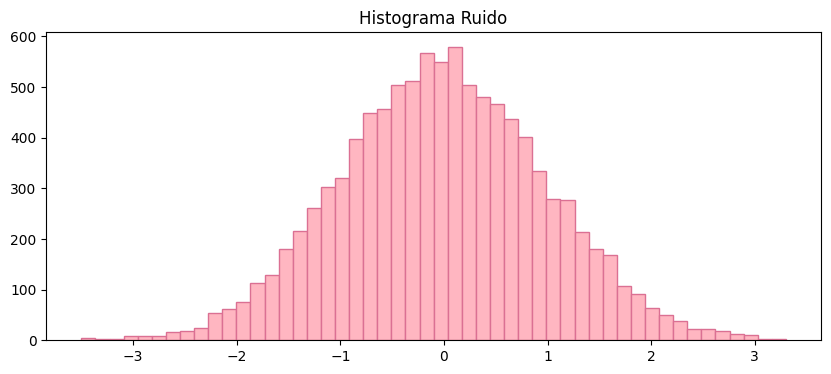

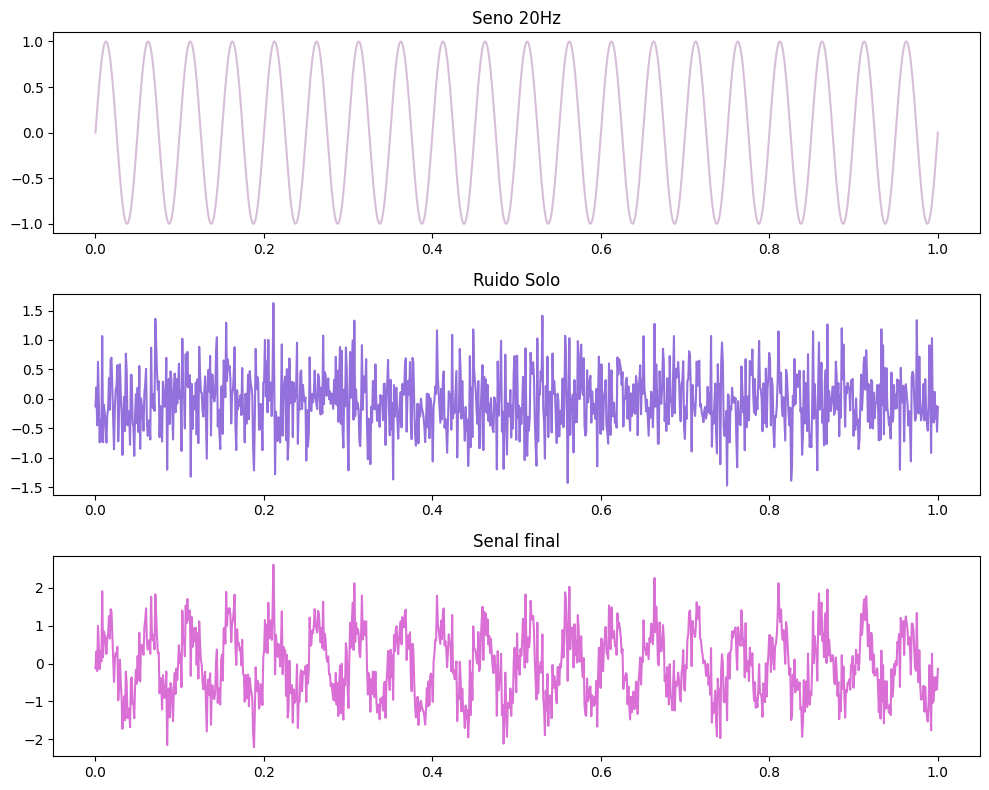

In [8]:
# Implementación de estadística y generación de ruido
#EJERCICIO 3. DISTRIBUCIONES DE PROBABILIDAD Y RUIDO
#3.1: Histograma
u=0
o=1 # media y sigma
datos = np.random.normal(u, o, 10000)

plt.figure(figsize=(10, 4))
plt.hist(datos, bins=50, color='lightpink', edgecolor='palevioletred')
plt.title("Histograma Ruido")
plt.show()

# 3.2 Seno 20Hz
fs= 1000
t= np.linspace(0, 1, fs)
fr= 20
s_pura= np.sin(2 * np.pi * fr * t)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, s_pura, color='thistle')
plt.title("Seno 20Hz")


# 3.3 Ruido
r= np.random.normal(0, 0.5, len(t))

plt.subplot(3, 1, 2)
plt.plot(t, r, color='mediumpurple')
plt.title("Ruido Solo")


# 3.4 Señal Final
s_final= s_pura + r

plt.subplot(3, 1, 3)
plt.plot(t, s_final, color='orchid')
plt.title("Senal final")

plt.tight_layout()
plt.show()

## 4. Muestreo y Teorema de Nyquist
### 4.1 Señal Impulso
Crea una señal delta $\delta(n)$ y desplázala en el tiempo.

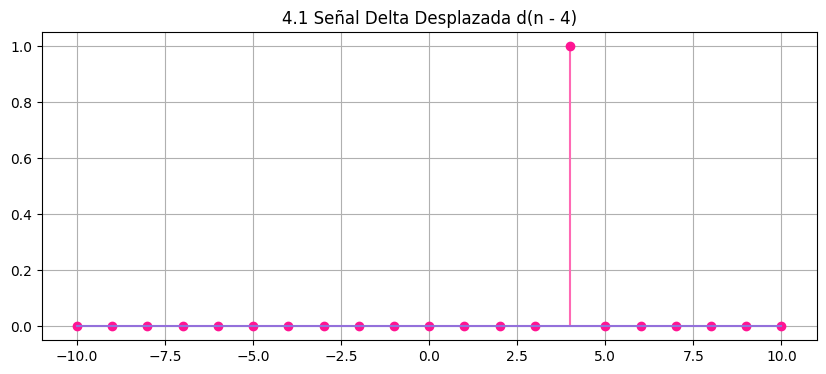

In [9]:
# Implementa una señal impulso desplazada
# 4.1 Señal Impulso

n = np.arange(-10, 11)
k = 4 # Desplazamiento
delta_desplazada = np.where(n == k, 1, 0)

plt.figure(figsize=(10, 4))
plt.stem(n, delta_desplazada, linefmt='hotpink', markerfmt='deeppink', basefmt='mediumpurple') #linefmt es el palito y markerfmt la bolita

plt.title(f"4.1 Señal Delta Desplazada d(n - {k})")
plt.grid(True)
plt.show()

### 4.2 Verificación de Nyquist
Demuestra qué sucede cuando la frecuencia de muestreo $f_s$ es menor, igual o mayor a $2 \cdot F_{max}$.

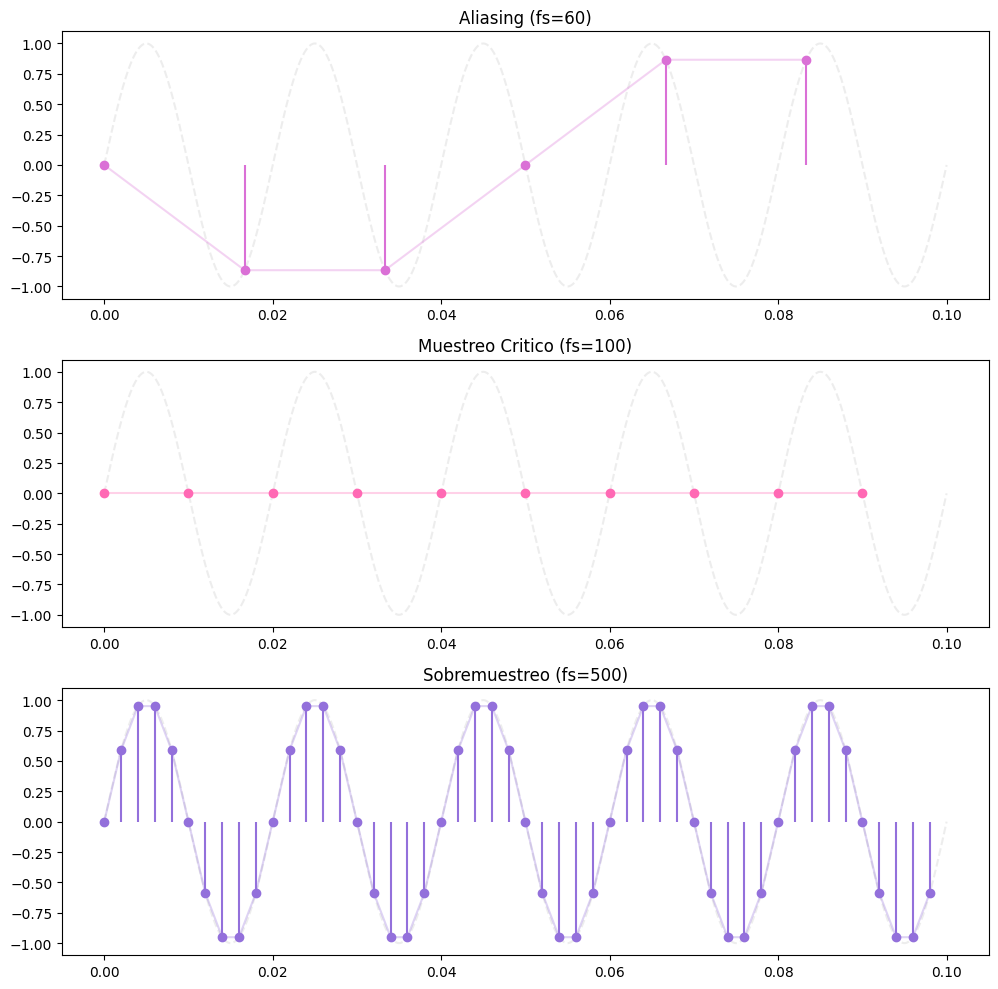

In [10]:
#Evalúa 3 casos de muestreo para una senoidal de 50Hz
# 4.2 Verificación de Nyquist
fm = 50 
tc = np.linspace(0, 0.1, 1000)
sr = np.sin(2 * np.pi * fm * tc)

plt.figure(figsize=(10, 10))

#Caso 1:(60Hz)
fs1 = 60
tm1 = np.arange(0, 0.1, 1/fs1)
sm1 = np.sin(2 * np.pi * fm * tm1)

plt.subplot(3, 1, 1)
plt.plot(tc, sr, '--', color='lightgray', alpha=0.4)
plt.stem(tm1, sm1, linefmt='orchid', markerfmt='orchid', basefmt=" ")
plt.plot(tm1, sm1, color='orchid', alpha=0.3)
plt.title("Aliasing (fs=60)")

#Caso 2:(100Hz)
fs2 = 100
tm2 = np.arange(0, 0.1, 1/fs2)
sm2 = np.sin(2 * np.pi * fm * tm2)

plt.subplot(3, 1, 2)
plt.plot(tc, sr, '--', color='lightgray', alpha=0.4)
plt.stem(tm2, sm2, linefmt='hotpink', markerfmt='hotpink', basefmt=" ")
plt.plot(tm2, sm2, color='hotpink', alpha=0.3)
plt.title("Muestreo Critico (fs=100)")

#Caso 3:(500Hz) 
fs3 = 500
tm3 = np.arange(0, 0.1, 1/fs3)
sm3 = np.sin(2 * np.pi * fm * tm3)

plt.subplot(3, 1, 3)
plt.plot(tc, sr, '--', color='lightgray', alpha=0.4)
plt.stem(tm3, sm3, linefmt='mediumpurple', markerfmt='mediumpurple', basefmt=" ")
plt.plot(tm3, sm3, color='mediumpurple', alpha=0.3)
plt.title("Sobremuestreo (fs=500)")

plt.tight_layout()
plt.show()

## 5. Cuantización y Resolución de Bits
Simularemos el proceso de discretización en amplitud.

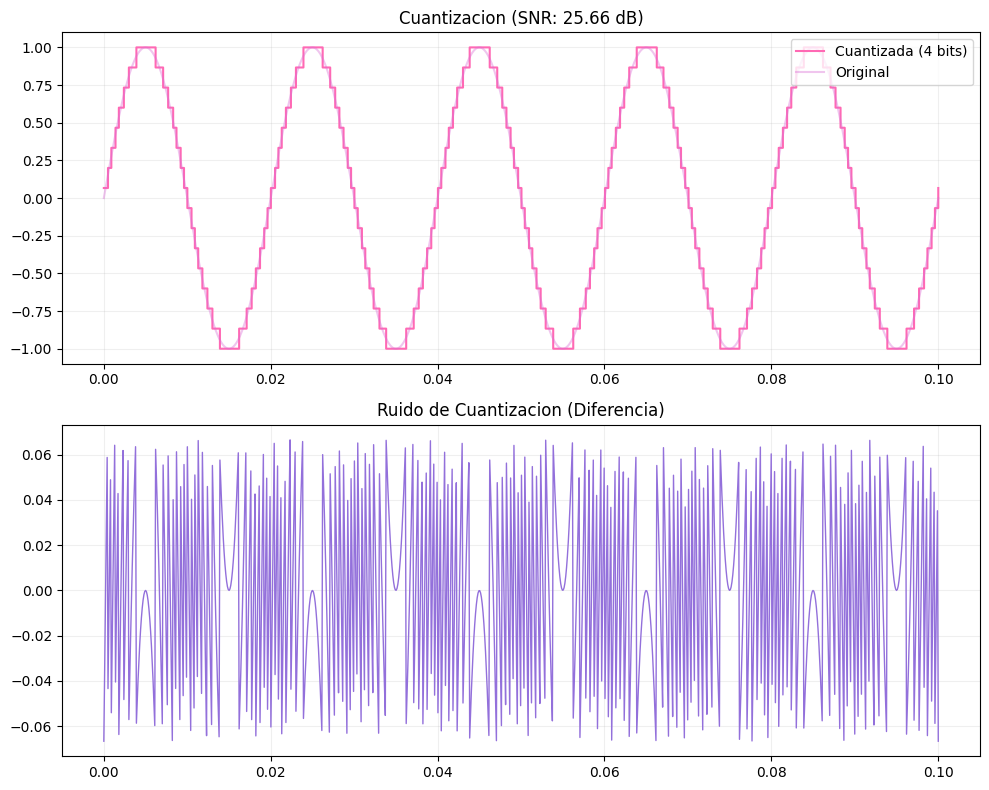

In [ ]:
# Toma una señal y cuantízala a 4 bits (16 niveles).
# Calcula y grafica el SNR (Signal-to-Noise Ratio) del error de cuantización.
b = 4 # cantidad de bits
n_niveles = 2**b
t = np.linspace(0, 0.1, 1000)
sig = np.sin(2 * np.pi * 50 * t) # señal original

# Proceso de cuantizacion (paso a paso)
sig_norm = (sig + 1) / 2 * (n_niveles - 1)
sig_c = (np.round(sig_norm) / (n_niveles - 1) * 2) - 1

# Calculo de ruido y calidad
err = sig - sig_c
p_sig = np.mean(sig**2)
p_err = np.mean(err**2)
valor_snr = 10 * np.log10(p_sig / p_err)

plt.figure(figsize=(10, 8))

# Grafica principal
plt.subplot(2, 1, 1)
plt.step(t, sig_c, color='hotpink', where='post', label=f"Cuantizada ({b} bits)")
plt.plot(t, sig, color='orchid', alpha=0.4, label="Original")
plt.title(f"Cuantizacion (SNR: {valor_snr:.2f} dB)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

# Grafica del error (ruido)
plt.subplot(2, 1, 2)
plt.plot(t, err, color='mediumpurple', linewidth=1)
plt.title("Ruido de Cuantizacion")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Análisis de Vibraciones: Caso de Ingeniería
Un motor gira a 60 Hz (rotación normal) pero tiene una falla de desalineación que genera un componente de 120 Hz. El entorno tiene mucho ruido.

**Tarea:**
1. Genera la señal mixta ruidosa.
2. Identifica las frecuencias mediante la FFT.

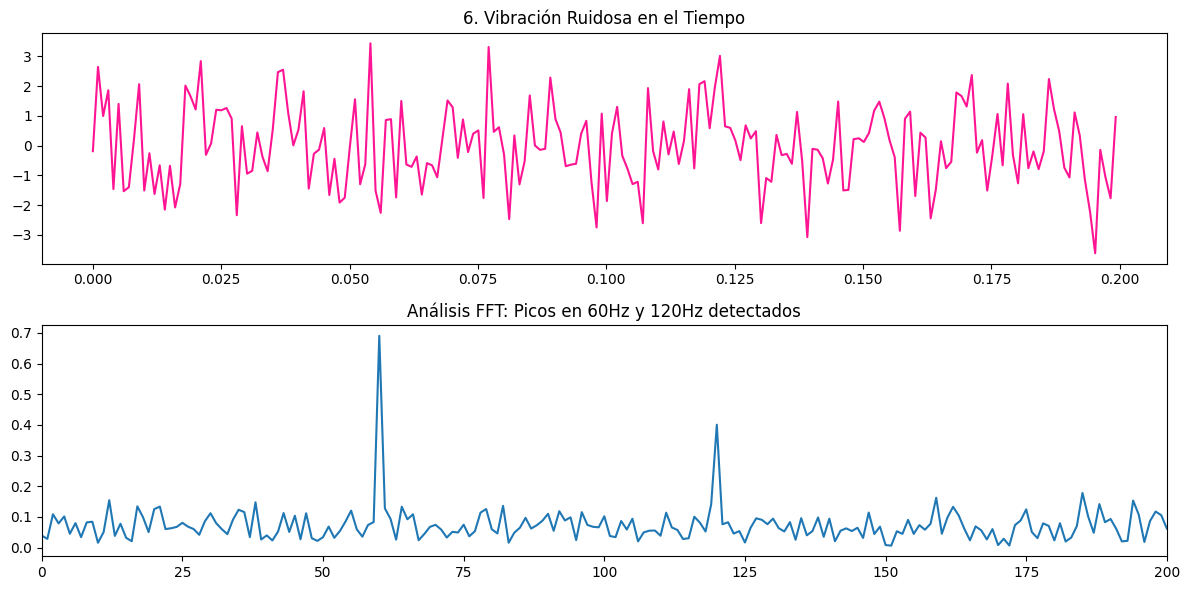

In [ ]:
fs = 1000
t = np.linspace(0, 1, fs)
f_rotation = 60
f_fault = 120

# Señal con ruido blanco gaussiano
signal_clean = 0.7 * np.sin(2 * np.pi * f_rotation * t) + 0.4 * np.sin(2 * np.pi * f_fault * t)
noisy_signal = signal_clean + np.random.normal(0, 1.2, len(t))

# Aplica FFT y grafica
# FFT
n_v = len(t)
frecuencias_v = fftfreq(n_v, 1/fs)[:n_v//2]
mag_v = (2.0/n_v) * np.abs(fft(noisy_signal)[:n_v//2])

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t[:200], noisy_signal[:200], color='deeppink')
plt.title("Vibración Ruidosa en el Tiempo")
plt.subplot(2, 1, 2)
plt.plot(frecuencias_v, mag_v)
plt.title("Análisis FFT: Picos en 60Hz y 120Hz detectados")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

## 7. Frecuencia Espacial en Imágenes
Las imágenes también tienen frecuencias. Cambios rápidos (bordes) son altas frecuencias; áreas suaves son bajas frecuencias.

**Tarea:**
1. Genera una rejilla senoidal (sinusoidal grating).
2. Aplica la FFT 2D y observa el espectro centrado.

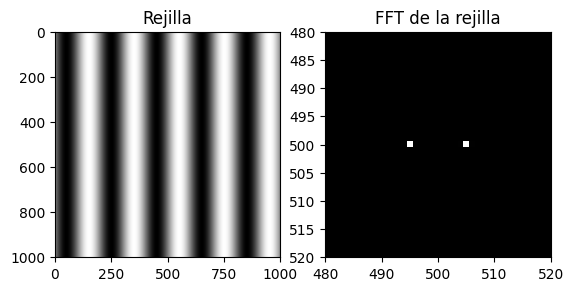

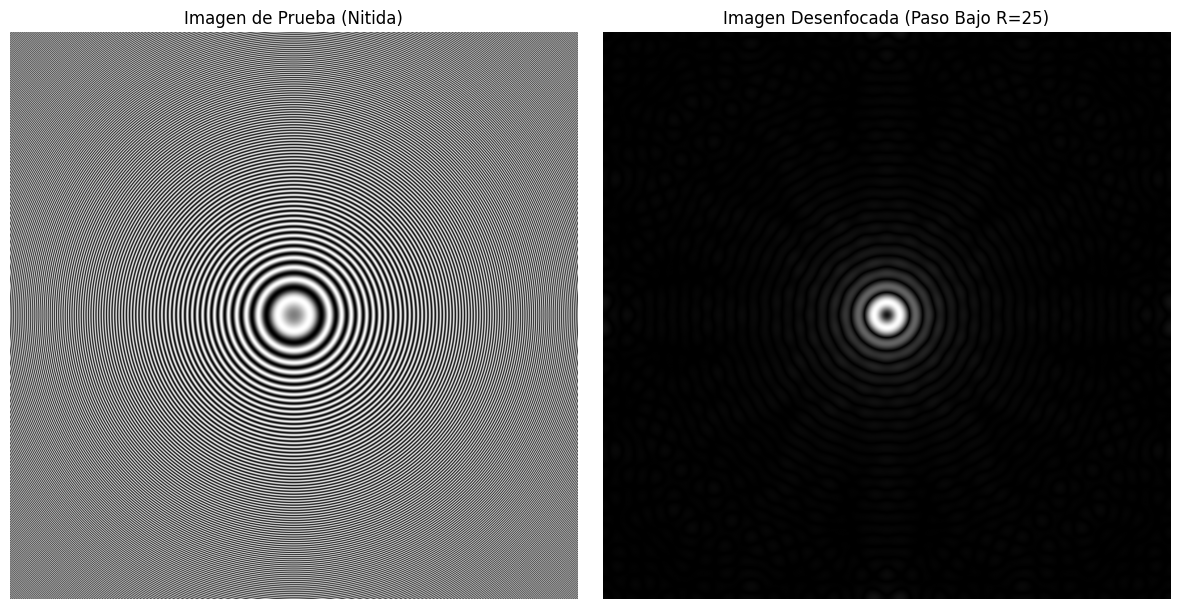

In [31]:
x = np.arange(-500, 501, 1)  # el eje para la malla

X, Y = np.meshgrid(x, x)  # armamos la grilla 2D

largo_onda = 200  # que tan separadas estan las rayas
angulo = 0  # inclinacion
rej = np.sin(2*np.pi*(X*np.cos(angulo) + Y*np.sin(angulo)) / largo_onda)  # la señal base

plt.set_cmap("gray")

plt.subplot(121) 
plt.imshow(rej) 
plt.title("Rejilla") 

ft_aux = np.fft.ifftshift(rej)
trans = np.fft.fft2(ft_aux)  
ft = np.fft.fftshift(trans)  

plt.subplot(122)  
plt.imshow(abs(ft))  
plt.xlim([480, 520])  
plt.ylim([520, 480]) 
plt.title("FFT de la rejilla") 
plt.show()  

#7.3 FILTRO PASO BAJO CIRCULAR 

dist_radial = np.sqrt(X**2 + Y**2)  
img = np.sin(dist_radial**2 / 500) 

# pasamos a frecuencia
img_fft = np.fft.fftshift(np.fft.fft2(img))  

# configuramos el filtro circular
filas, cols = img.shape  
cx= cols // 2
cy =filas // 2  
rad = 25  # si quieres mas desenfoque, baja este numero a 10

# mascara del filtro
y_m, x_m = np.ogrid[:filas, :cols]  
mascara = (x_m - cx)**2 + (y_m - cy)**2 <= rad**2  

# aplicamos y volvemos al espacio
ft_filtrada = img_fft * mascara  
img_final = np.abs(np.fft.ifft2(np.fft.ifftshift(ft_filtrada)))  

# comparacion
plt.figure(figsize=(12, 6))  

plt.subplot(1, 2, 1)  
plt.imshow(img, cmap='gray')  # original con bordes filosos
plt.title("Imagen de Prueba (Nitida)")  
plt.axis('off')  

plt.subplot(1, 2, 2)  
plt.imshow(img_final, cmap='gray')  # resultado borroso
plt.title(f"Imagen Desenfocada (Paso Bajo R={rad})")  
plt.axis('off')  

plt.tight_layout()  
plt.show()

## 8. Conclusiones y Preguntas Teóricas
- ¿Cómo afecta la desviación estándar del ruido gaussiano a la legibilidad del espectro en la FFT?

Respuesta: Eleva el piso de ruido en la gráfica. Al aumentar la desviación estándar, el ruido se vuelve más fuerte y puede llegar a ocultar los picos de las frecuencias reales, haciendo que la señal principal deje de ser legible.

- Explica por qué un cambio brusco de color en una imagen (un borde) genera componentes de alta frecuencia en el espectro 2D.

Respuesta: Porque los bordes representan cambios rápidos en la intensidad de los píxeles. En el análisis de Fourier, cualquier transición súbita o detalle fino se traduce matemáticamente como componentes de alta frecuencia, que son los puntos que aparecen lejos del centro en el espectro.

- ¿Qué relación existe entre la resolución de cuantización y el rango dinámico de un sistema de audio?

Respuesta: La relación es directa es decir, a mayor cantidad de bits, mayor es el rango dinámico del sistema. Esto permite captar mejor la diferencia entre los sonidos más suaves y los más fuertes, sumando aproximadamente 6 dB de rango por cada bit adicional.

## 9. Referencias

[Generate colors of noise in Python] https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python

[Generación de señales] https://medium.com/@martinkarlsson.io/fourier-transform-in-python-f15b3243ce9a

[Fourier Transform] https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.04-FFT-in-Python.html

[SciPy] https://docs.scipy.org/doc/scipy/tutorial/fft.html

[Fourier con numpy] https://towardsdatascience.com/fourier-transform-the-practical-python-implementation-acdd32f1b96a

[Sobre Teorema del sampleo] https://ipython-books.github.io/chapter-10-signal-processing/

[Sobre Matplotlib] https://matplotlib.org/stable/gallery/mplot3d/2dcollections3d.html

[2D meshing] https://thepythoncodingbook.com/2021/08/30/2d-fourier-transform-in-python-and-fourier-synthesis-of-images/

[Numerical Methods] https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html